In [1]:
import torch
torch.__version__

'2.2.2+cpu'

# Tensors

In [2]:
# Simple Tensors
a = torch.tensor([[1,2],[3,4]]) # lists of np-arrays
print(a)
a = torch.randn(size=(10,3)) # random
print(a)

tensor([[1, 2],
        [3, 4]])
tensor([[-0.2097,  1.1475,  0.6216],
        [-0.5579,  0.4217, -1.1494],
        [-1.0965, -0.5102, -1.0295],
        [-0.8773, -0.4256,  0.7498],
        [ 1.2117, -0.0332,  0.1275],
        [-0.1456,  1.3616, -0.7864],
        [-1.9339,  1.3166, -0.2813],
        [-1.3595, -1.8283, -0.4401],
        [ 0.2588,  1.4446,  0.1702],
        [-2.1844,  0.5594, -1.4966]])


In [3]:
print(a-a[0])
print(torch.exp(a)[0].numpy()) # extract first row (numpy-array) and convert to numpy

tensor([[ 0.0000,  0.0000,  0.0000],
        [-0.3482, -0.7259, -1.7710],
        [-0.8868, -1.6577, -1.6511],
        [-0.6676, -1.5732,  0.1282],
        [ 1.4214, -1.1807, -0.4942],
        [ 0.0642,  0.2140, -1.4080],
        [-1.7242,  0.1690, -0.9029],
        [-1.1497, -2.9758, -1.0617],
        [ 0.4685,  0.2971, -0.4515],
        [-1.9746, -0.5881, -2.1182]])
[0.8107914 3.1504629 1.8619572]


In [4]:
# using tensor operation add
u = torch.tensor(5)
print("Result when adding out-of-place:",u.add(torch.tensor(3))) # adding out-of-place
u.add_(torch.tensor(3)) # adding in-place
print("Result after adding in-place:", u)

Result when adding out-of-place: tensor(8)
Result after adding in-place: tensor(8)


In [5]:
# sum of all rows in a tensor
s = torch.zeros_like(a[0])
for i in a:
  s.add_(i)
print(s)

# even better way
torch.sum(a,axis=0)

tensor([-6.8944,  3.4542, -3.5141])


tensor([-6.8944,  3.4542, -3.5141])

# Computing Gradients

In [6]:
a = torch.randn(size=(2, 2), requires_grad=True) # setting requires_grad=True to track gradient calculations
b = torch.randn(size=(2, 2))

c = torch.mean(torch.sqrt(torch.square(a) + torch.square(b)))  # Do some math using `a`
c.backward() # call backward() to compute all gradients
# What's the gradient of `c` with respect to `a`?
print(a.grad) # grad gives the gradient of c with respect to a, which is dc/da. Tells us how much c changes with respect to a

tensor([[-0.2396,  0.1166],
        [ 0.0054, -0.2495]])


In [7]:
c = torch.mean(torch.sqrt(torch.square(a) + torch.square(b)))
c.backward(retain_graph=True) # retain_graph=True allows us to call backward() multiple times on the same graph without freeing the computational graph
c.backward(retain_graph=True)
print(a.grad)
a.grad.zero_() # zero_() resets gradient to zero
c.backward()
print(a.grad)

tensor([[-0.7188,  0.3499],
        [ 0.0162, -0.7485]])
tensor([[-0.2396,  0.1166],
        [ 0.0054, -0.2495]])


In [8]:
print(c) # grad_fn computes derivative of the expression according to the chain rule
# c computed using mean therefore grad_fn = MeanBackward0

tensor(0.8353, grad_fn=<MeanBackward0>)


In [9]:
c = torch.sqrt(torch.square(a) + torch.square(b))
c.backward(torch.eye(2)) # eye(2) means 2x2 identity matrix. number should march the shape of c
print(a.grad)

tensor([[-1.1979,  0.1166],
        [ 0.0054, -1.2475]])


# Example 0: Optimisation Using Gradient Descent

In [10]:
x = torch.zeros(2,requires_grad=True) # define starting value
f = lambda x : (x-torch.tensor([3,-2])).pow(2).sum() # define function f(x) = (x-3)^2 + (x+2)^2
lr = 0.1

In [11]:
for i in range(15): # 15 iterations of gradient descent
    y = f(x)
    y.backward()
    gr = x.grad
    x.data.add_(-lr*gr) # update x using the gradient and learning rate
    x.grad.zero_()
    print("Step {}: x[0]={}, x[1]={}".format(i,x[0],x[1])) # checking to make sure x is approaching the minimum of f(x) which is at (3,-2)

Step 0: x[0]=0.6000000238418579, x[1]=-0.4000000059604645
Step 1: x[0]=1.0800000429153442, x[1]=-0.7200000286102295
Step 2: x[0]=1.4639999866485596, x[1]=-0.9760000705718994
Step 3: x[0]=1.7711999416351318, x[1]=-1.1808000802993774
Step 4: x[0]=2.0169599056243896, x[1]=-1.3446400165557861
Step 5: x[0]=2.2135679721832275, x[1]=-1.4757120609283447
Step 6: x[0]=2.370854377746582, x[1]=-1.5805696249008179
Step 7: x[0]=2.4966835975646973, x[1]=-1.6644556522369385
Step 8: x[0]=2.597346782684326, x[1]=-1.7315645217895508
Step 9: x[0]=2.677877426147461, x[1]=-1.7852516174316406
Step 10: x[0]=2.7423019409179688, x[1]=-1.8282012939453125
Step 11: x[0]=2.793841600418091, x[1]=-1.8625609874725342
Step 12: x[0]=2.835073232650757, x[1]=-1.8900487422943115
Step 13: x[0]=2.868058681488037, x[1]=-1.912039041519165
Step 14: x[0]=2.894446849822998, x[1]=-1.929631233215332


# Example 1: Linear Regression

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
import random

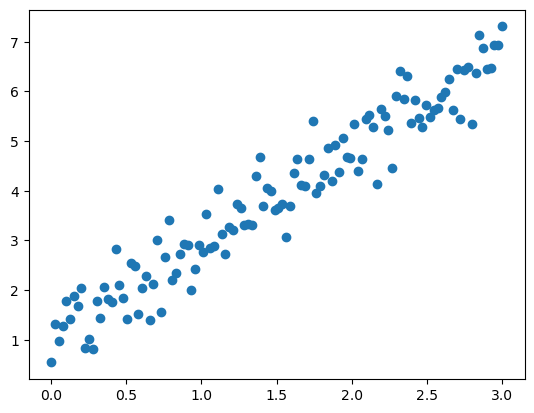

In [13]:
np.random.seed(13) # pick the seed for reproducibility - change it to explore the effects of random variations

train_x = np.linspace(0, 3, 120)
train_labels = 2 * train_x + 0.9 + np.random.randn(*train_x.shape) * 0.5

plt.scatter(train_x,train_labels)

In [14]:
input_dim = 1
output_dim = 1
learning_rate = 0.1

# This is our weight matrix
w = torch.tensor([100.0],requires_grad=True,dtype=torch.float32)
# This is our bias vector
b = torch.zeros(size=(output_dim,),requires_grad=True)

def f(x): # model function
  return torch.matmul(x,w) + b

def compute_loss(labels, predictions): # loss function
  return torch.mean(torch.square(labels - predictions))

In [15]:
# Used for training the model on series of minibatches
def train_on_batch(x, y):
  predictions = f(x)
  loss = compute_loss(y, predictions)
  loss.backward()
  w.data.sub_(learning_rate * w.grad) # update weights using the gradient and learning rate
  b.data.sub_(learning_rate * b.grad) # update bias using the gradient and learning rate
  w.grad.zero_()
  b.grad.zero_()
  return loss

In [16]:
# Shuffle the data.
indices = np.random.permutation(len(train_x))
features = torch.tensor(train_x[indices],dtype=torch.float32)
labels = torch.tensor(train_labels[indices],dtype=torch.float32)

In [17]:
# Training
batch_size = 4
for epoch in range(10):
  for i in range(0,len(features),batch_size):
    loss = train_on_batch(features[i:i+batch_size].view(-1,1),labels[i:i+batch_size])
  print('Epoch %d: last batch loss = %.4f' % (epoch, float(loss)))

Epoch 0: last batch loss = 94.5247
Epoch 1: last batch loss = 9.3428
Epoch 2: last batch loss = 1.4166
Epoch 3: last batch loss = 0.5224
Epoch 4: last batch loss = 0.3807
Epoch 5: last batch loss = 0.3495
Epoch 6: last batch loss = 0.3413
Epoch 7: last batch loss = 0.3390
Epoch 8: last batch loss = 0.3384
Epoch 9: last batch loss = 0.3382


In [18]:
w,b # optimised weights and bias after training. values similar to original values of W and b

(tensor([1.8617], requires_grad=True), tensor([1.0711], requires_grad=True))

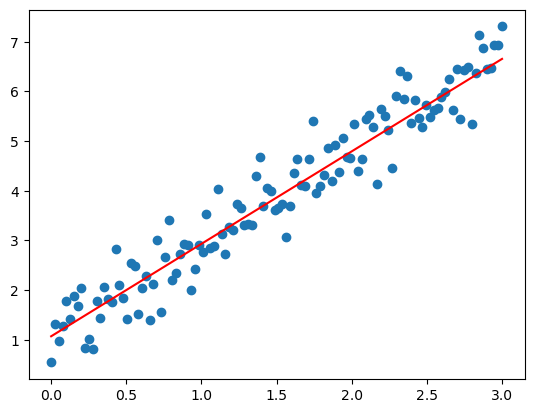

In [19]:
plt.scatter(train_x,train_labels)
x = np.array([min(train_x),max(train_x)])
with torch.no_grad():
  y = w.numpy()*x+b.numpy()
plt.plot(x,y,color='red')

# Computations on GPU

In [20]:
# Setting available device for computations and then moving the model parameters to that device
# Such code works without any changes on both CPU and GPU.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Doing computations on '+device)

### Changes here: indicate device
w = torch.tensor([100.0],requires_grad=True,dtype=torch.float32,device=device)
b = torch.zeros(size=(output_dim,),requires_grad=True,device=device)

def f(x):
  return torch.matmul(x,w) + b

def compute_loss(labels, predictions):
  return torch.mean(torch.square(labels - predictions))

def train_on_batch(x, y):
  predictions = f(x)
  loss = compute_loss(y, predictions)
  loss.backward()
  w.data.sub_(learning_rate * w.grad)
  b.data.sub_(learning_rate * b.grad)
  w.grad.zero_()
  b.grad.zero_()
  return loss

batch_size = 4
for epoch in range(10):
  for i in range(0,len(features),batch_size):
    ### Changes here: move data to required device
    loss = train_on_batch(features[i:i+batch_size].view(-1,1).to(device),labels[i:i+batch_size].to(device))
  print('Epoch %d: last batch loss = %.4f' % (epoch, float(loss)))

Doing computations on cpu
Epoch 0: last batch loss = 94.5247
Epoch 1: last batch loss = 9.3428
Epoch 2: last batch loss = 1.4166
Epoch 3: last batch loss = 0.5224
Epoch 4: last batch loss = 0.3807
Epoch 5: last batch loss = 0.3495
Epoch 6: last batch loss = 0.3413
Epoch 7: last batch loss = 0.3390
Epoch 8: last batch loss = 0.3384
Epoch 9: last batch loss = 0.3382


# Example 2: Classification

In [21]:
np.random.seed(0) # pick the seed for reproducibility - change it to explore the effects of random variations

n = 100
X, Y = make_classification(n_samples = n, n_features=2,
                           n_redundant=0, n_informative=2, flip_y=0.1,class_sep=1.5)
X = X.astype(np.float32)
Y = Y.astype(np.int32)

split = [ 70*n//100, (15+70)*n//100 ]
train_x, valid_x, test_x = np.split(X, split)
train_labels, valid_labels, test_labels = np.split(Y, split)

In [22]:
def plot_dataset(features, labels, W=None, b=None):
    # prepare the plot
    fig, ax = plt.subplots(1, 1)
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')
    colors = ['r' if l else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=100, alpha = 0.5)
    if W is not None:
        min_x = min(features[:,0])
        max_x = max(features[:,1])
        min_y = min(features[:,1])*(1-.1)
        max_y = max(features[:,1])*(1+.1)
        cx = np.array([min_x,max_x],dtype=np.float32)
        cy = (0.5-W[0]*cx-b)/W[1]
        ax.plot(cx,cy,'g')
        ax.set_ylim(min_y,max_y)

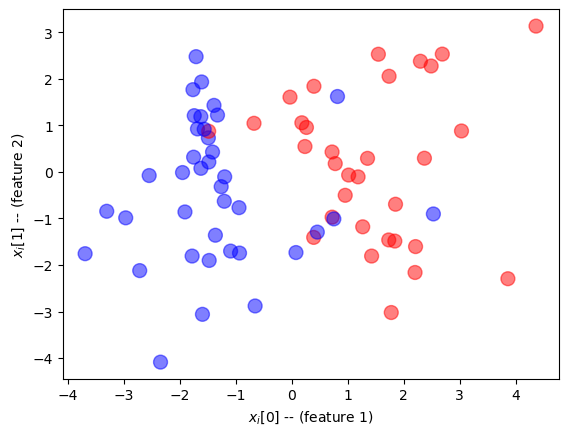

In [23]:
plot_dataset(train_x, train_labels)

# Training One-Layer Perceptron

In [24]:
class Network():
  def __init__(self):
     self.W = torch.randn(size=(2,1),requires_grad=True)
     self.b = torch.zeros(size=(1,),requires_grad=True)

  def forward(self,x):
    return torch.matmul(x,self.W)+self.b

  def zero_grad(self):
    self.W.data.zero_() # using data.zero_() instead of zero_() because you cant directly change tensor that is being tracked using Autograd
    self.b.data.zero_()

  def update(self,lr=0.1):
    self.W.data.sub_(lr*self.W.grad)
    self.b.data.sub_(lr*self.b)

net = Network()

In [25]:
def train_on_batch(net, x, y):
  z = net.forward(x).flatten()
  loss = torch.nn.functional.binary_cross_entropy_with_logits(input=z,target=y) # binary_cross_entropy_with_logits is equivalent to calling sigmoid and then binary_cross_entropy
  net.zero_grad()
  loss.backward()
  net.update()
  return loss

In [26]:
# Create a tf.data.Dataset object for easy batched iteration
dataset = torch.utils.data.TensorDataset(torch.tensor(train_x),torch.tensor(train_labels,dtype=torch.float32))
dataloader = torch.utils.data.DataLoader(dataset,batch_size=16)

list(dataloader)[0]

[tensor([[ 1.5442,  2.5290],
         [-1.6284,  0.0772],
         [-1.7141,  2.4770],
         [-1.4951,  0.7320],
         [-1.6899,  0.9243],
         [-0.9474, -0.7681],
         [ 3.8597, -2.2951],
         [-1.3944,  1.4300],
         [ 4.3627,  3.1333],
         [-1.0973, -1.7011],
         [-2.5532, -0.0777],
         [-1.2661, -0.3167],
         [ 0.3921,  1.8406],
         [ 2.2091, -1.6045],
         [ 1.8383, -1.4861],
         [ 0.7173, -0.9718]]),
 tensor([1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1.])]

In [27]:
# Loop through dataset to train network for 15 epochs
for epoch in range(15):
  for (x, y) in dataloader:
    loss = train_on_batch(net,x,y)
  print('Epoch %d: last batch loss = %.4f' % (epoch, float(loss)))

Epoch 0: last batch loss = 0.5585
Epoch 1: last batch loss = 0.4606
Epoch 2: last batch loss = 0.3997
Epoch 3: last batch loss = 0.3580
Epoch 4: last batch loss = 0.3274
Epoch 5: last batch loss = 0.3038
Epoch 6: last batch loss = 0.2850
Epoch 7: last batch loss = 0.2695
Epoch 8: last batch loss = 0.2565
Epoch 9: last batch loss = 0.2454
Epoch 10: last batch loss = 0.2358
Epoch 11: last batch loss = 0.2274
Epoch 12: last batch loss = 0.2199
Epoch 13: last batch loss = 0.2132
Epoch 14: last batch loss = 0.2072


In [28]:
print(net.W,net.b) # trained weights and bias after training

tensor([[1.3884],
        [0.3497]], requires_grad=True) tensor([0.], requires_grad=True)


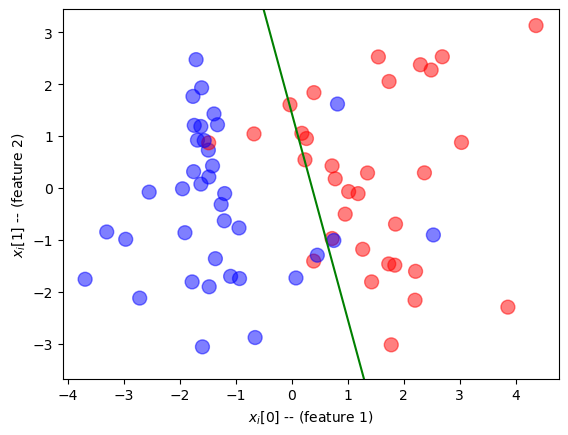

In [29]:
# The line separates the two classes in the dataset
plot_dataset(train_x,train_labels,net.W.detach().numpy(),net.b.detach().numpy())

In [30]:
# compute accuracy on validation set
pred = torch.sigmoid(net.forward(torch.tensor(valid_x)))
torch.mean(((pred.view(-1)>0.5)==(torch.tensor(valid_labels)>0.5)).type(torch.float32))

tensor(0.8000)

# Neural Networks and Optimisers

In [31]:
# training one built-in linear layer using torch.nn.Linear
net = torch.nn.Linear(2,1) # 2 inputs, 1 output

print(list(net.parameters())) # returns parameters that need to be adjusted during training

[Parameter containing:
tensor([[ 0.0923, -0.1604]], requires_grad=True), Parameter containing:
tensor([0.6758], requires_grad=True)]


In [32]:
# Stochastic gradient descent optimiser for training the model
optim = torch.optim.SGD(net.parameters(),lr=0.05)

In [33]:
# Training loop when using the optimiser
val_x = torch.tensor(valid_x)
val_lab = torch.tensor(valid_labels)

for ep in range(10):
  for (x,y) in dataloader:
    z = net(x).flatten() # using net(x) instead of net.forward(x) because the forward method is called automatically when you call the object
    loss = torch.nn.functional.binary_cross_entropy_with_logits(z,y)
    optim.zero_grad()
    loss.backward()
    optim.step()
  acc = ((torch.sigmoid(net(val_x).flatten())>0.5).float()==val_lab).float().mean()
  print(f"Epoch {ep}: last batch loss = {loss}, val acc = {acc}")

Epoch 0: last batch loss = 0.7370138764381409, val acc = 0.46666666865348816
Epoch 1: last batch loss = 0.6450492739677429, val acc = 0.6000000238418579
Epoch 2: last batch loss = 0.575049102306366, val acc = 0.7333333492279053
Epoch 3: last batch loss = 0.5206714272499084, val acc = 0.800000011920929
Epoch 4: last batch loss = 0.47748899459838867, val acc = 0.800000011920929
Epoch 5: last batch loss = 0.4424760043621063, val acc = 0.800000011920929
Epoch 6: last batch loss = 0.4135531187057495, val acc = 0.800000011920929
Epoch 7: last batch loss = 0.38926780223846436, val acc = 0.800000011920929
Epoch 8: last batch loss = 0.36858394742012024, val acc = 0.800000011920929
Epoch 9: last batch loss = 0.35074785351753235, val acc = 0.800000011920929


In [34]:
# Generic train function
def train(net, dataloader, val_x, val_lab, epochs=10, lr=0.05):
  optim = torch.optim.Adam(net.parameters(),lr=lr)
  for ep in range(epochs):
    for (x,y) in dataloader:
      z = net(x).flatten()
      loss = torch.nn.functional.binary_cross_entropy_with_logits(z,y)
      optim.zero_grad()
      loss.backward()
      optim.step()
    acc = ((torch.sigmoid(net(val_x).flatten())>0.5).float()==val_lab).float().mean()
    print(f"Epoch {ep}: last batch loss = {loss}, val acc = {acc}")

net = torch.nn.Linear(2,1)

train(net,dataloader,val_x,val_lab,lr=0.03)

Epoch 0: last batch loss = 0.9708437323570251, val acc = 0.3333333432674408
Epoch 1: last batch loss = 0.869271457195282, val acc = 0.4000000059604645
Epoch 2: last batch loss = 0.7749573588371277, val acc = 0.46666666865348816
Epoch 3: last batch loss = 0.689353883266449, val acc = 0.5333333611488342
Epoch 4: last batch loss = 0.6137202978134155, val acc = 0.7333333492279053
Epoch 5: last batch loss = 0.5488073825836182, val acc = 0.6666666865348816
Epoch 6: last batch loss = 0.4944978952407837, val acc = 0.7333333492279053
Epoch 7: last batch loss = 0.44977203011512756, val acc = 0.7333333492279053
Epoch 8: last batch loss = 0.41304945945739746, val acc = 0.800000011920929
Epoch 9: last batch loss = 0.38265812397003174, val acc = 0.800000011920929


# Defining Networks as a Sequence of Layers

In [35]:
# Listing the sequence of layers using torch.nn.Sequential
net = torch.nn.Sequential(torch.nn.Linear(2,5),torch.nn.Sigmoid(),torch.nn.Linear(5,1))
print(net)

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=5, out_features=1, bias=True)
)


In [36]:
train(net,dataloader,val_x,val_lab) # training multi-layered network

Epoch 0: last batch loss = 0.6239030957221985, val acc = 0.6000000238418579


Epoch 1: last batch loss = 0.544632613658905, val acc = 0.6000000238418579
Epoch 2: last batch loss = 0.47124385833740234, val acc = 0.6666666865348816
Epoch 3: last batch loss = 0.4038267433643341, val acc = 0.7333333492279053
Epoch 4: last batch loss = 0.3452777564525604, val acc = 0.8666666746139526
Epoch 5: last batch loss = 0.29505476355552673, val acc = 0.800000011920929
Epoch 6: last batch loss = 0.2514002025127411, val acc = 0.800000011920929
Epoch 7: last batch loss = 0.2135438174009323, val acc = 0.800000011920929
Epoch 8: last batch loss = 0.1812639832496643, val acc = 0.800000011920929
Epoch 9: last batch loss = 0.15422864258289337, val acc = 0.800000011920929


# Defining a Network as a Class

In [37]:
class MyNet(torch.nn.Module):
  # defining layers in the constructor
  def __init__(self,hidden_size=10,func=torch.nn.Sigmoid()):
    super().__init__()
    self.fc1 = torch.nn.Linear(2,hidden_size)
    self.func = func
    self.fc2 = torch.nn.Linear(hidden_size,1)

  def forward(self,x):
    x = self.fc1(x)
    x = self.func(x)
    x = self.fc2(x)
    return x
  
net = MyNet(func=torch.nn.ReLU())
print(net)

MyNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (func): ReLU()
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)


In [38]:
train(net,dataloader,val_x,val_lab,lr=0.005)

Epoch 0: last batch loss = 0.6128664016723633, val acc = 0.7333333492279053
Epoch 1: last batch loss = 0.5706875324249268, val acc = 0.7333333492279053
Epoch 2: last batch loss = 0.5298399329185486, val acc = 0.7333333492279053
Epoch 3: last batch loss = 0.48999229073524475, val acc = 0.800000011920929
Epoch 4: last batch loss = 0.45214125514030457, val acc = 0.800000011920929
Epoch 5: last batch loss = 0.4163738489151001, val acc = 0.8666666746139526
Epoch 6: last batch loss = 0.3828904926776886, val acc = 0.8666666746139526
Epoch 7: last batch loss = 0.35254594683647156, val acc = 0.8666666746139526
Epoch 8: last batch loss = 0.3244645893573761, val acc = 0.8666666746139526
Epoch 9: last batch loss = 0.2987269163131714, val acc = 0.800000011920929


# Task 1
**Plot the graphs of loss function and accuracy on training and validation data during training**

In [39]:
train_losses = []
train_accs = []
val_losses = []
val_accs = []

def train(net, dataloader, val_x, val_lab, epochs=10, lr=0.05):
  optim = torch.optim.Adam(net.parameters(),lr=lr)
  for ep in range(epochs):
    for (x,y) in dataloader:
      z = net(x).flatten()
      val_lab = val_lab.float()

      # train and validation loss
      train_loss = torch.nn.functional.binary_cross_entropy_with_logits(z,y)
      val_loss = torch.nn.functional.binary_cross_entropy_with_logits(net(val_x).flatten(), val_lab)
      optim.zero_grad()
      train_loss.backward()
      val_loss.backward()
      optim.step()

    # train and validation accuracy
    train_acc = ((torch.sigmoid(z)>0.5).float()==y).float().mean()
    val_acc = ((torch.sigmoid(net(val_x).flatten())>0.5).float()==val_lab).float().mean()

    train_losses.append(train_loss.item())
    train_accs.append(train_acc.item())
    val_losses.append(val_loss.item())
    val_accs.append(val_acc.item())

net = torch.nn.Linear(2,1)

train(net,dataloader,val_x,val_lab,lr=0.03)

Plot Loss During Training

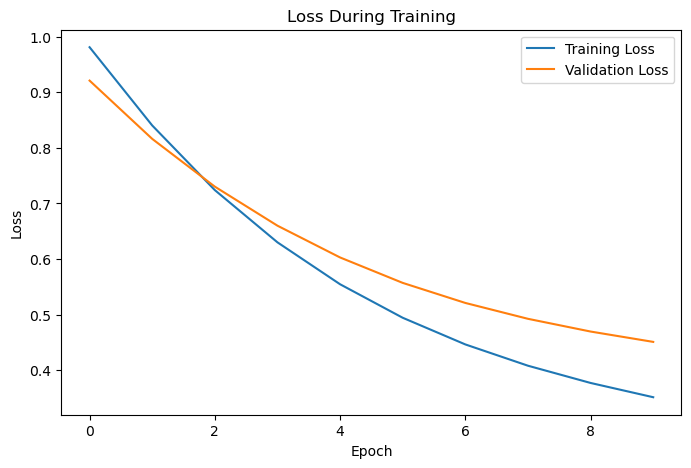

In [40]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss During Training")

plt.legend()
plt.show()

Plot Accuracy During Training

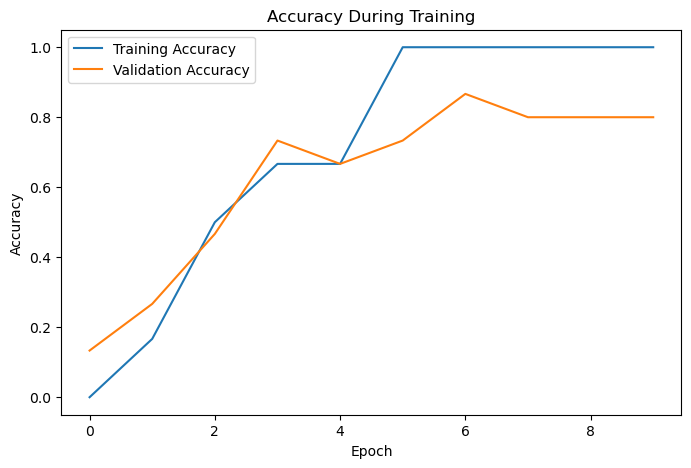

In [41]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Training Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy During Training")

plt.legend()
plt.show()

# Task 2
**Try to solve MNIST classificiation problem using this code. Hint: use `crossentropy_with_logits` as a loss function.**

In [42]:
# Using Python's urllib/gzip instead of wget/gzip shell commands,
# since wget is not available by default on Windows
import urllib.request
import gzip
import shutil

url = "https://raw.githubusercontent.com/microsoft/AI-For-Beginners/main/data/mnist.pkl.gz"

urllib.request.urlretrieve(url, "mnist.pkl.gz")

with gzip.open("mnist.pkl.gz", "rb") as f_in:
    with open("mnist.pkl", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

import pickle
with open('mnist.pkl','rb') as f:
    raw_data = pickle.load(f, encoding='latin1') # Added encoding='latin1' to fix a Python 2 vs Python 3 pickle compatibility issue

# The downloaded pickle file uses the (train, valid, test) tuple format,
# not the {'Train': {...}, 'Test': {...}} dict format this notebook expects.
# Manually reconstructing the expected dictionary structure here.
training_data, validation_data, test_data = raw_data

MNIST = {
    'Train': {
        'Features': training_data[0],
        'Labels': training_data[1]
    },
    'Test': {
        'Features': test_data[0],
        'Labels': test_data[1]
    }
}

labels = MNIST['Train']['Labels']
data = MNIST['Train']['Features']

from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(data,labels,test_size=0.2)

In [43]:
train_x = torch.tensor(features_train, dtype=torch.float32)
train_labels = torch.tensor(labels_train, dtype=torch.long)
val_x = torch.tensor(features_test, dtype=torch.float32)
val_lab = torch.tensor(labels_test, dtype=torch.long)

dataset = torch.utils.data.TensorDataset(train_x, train_labels)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

def train(net, dataloader, val_x, val_lab, epochs=10, lr=0.05):
  optim = torch.optim.Adam(net.parameters(),lr=lr)
  for ep in range(epochs):
    for (x,y) in dataloader:
      z = net(x)
      loss = torch.nn.functional.cross_entropy(z,y)
      optim.zero_grad()
      loss.backward()
      optim.step()
    acc = ((net(val_x).argmax(dim=1)==val_lab).float().mean())
    print(f"Epoch {ep}: last batch loss = {loss}, val acc = {acc}")

net = torch.nn.Sequential(torch.nn.Linear(784,100),torch.nn.ReLU(),torch.nn.Linear(100,10))

train(net,dataloader,val_x,val_lab,lr=0.03)

Epoch 0: last batch loss = 1.576314926147461, val acc = 0.8744999766349792
Epoch 1: last batch loss = 0.5984474420547485, val acc = 0.8956000208854675
Epoch 2: last batch loss = 0.33756786584854126, val acc = 0.8805999755859375
Epoch 3: last batch loss = 0.36411333084106445, val acc = 0.8895999789237976
Epoch 4: last batch loss = 0.13107548654079437, val acc = 0.8858000040054321
Epoch 5: last batch loss = 0.4992090165615082, val acc = 0.8809999823570251
Epoch 6: last batch loss = 0.07197887450456619, val acc = 0.8888999819755554
Epoch 7: last batch loss = 0.17075267434120178, val acc = 0.887499988079071
Epoch 8: last batch loss = 0.2135331630706787, val acc = 0.8956999778747559
Epoch 9: last batch loss = 0.3204481601715088, val acc = 0.8889999985694885


# Defining a Network as PyTorch Lightning Module

In [44]:
import pytorch_lightning as pl

In [45]:
dataset = torch.utils.data.TensorDataset(
    torch.tensor(features_train, dtype=torch.float32),
    torch.tensor(labels_train, dtype=torch.long)
)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True, num_workers=15, persistent_workers=True)

valid_dataset = torch.utils.data.TensorDataset(
    torch.tensor(features_test, dtype=torch.float32),
    torch.tensor(labels_test, dtype=torch.long)
)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, batch_size=16, num_workers=15, persistent_workers=True)

In [46]:
class MyNetPL(pl.LightningModule):
    def __init__(self, hidden_size=100, func=torch.nn.ReLU()):
        super().__init__()
        self.fc1 = torch.nn.Linear(784, hidden_size)
        self.func = func
        self.fc2 = torch.nn.Linear(hidden_size, 10)
        self.val_losses = []  # Store losses for epoch
        self.val_accs = []    # Store accuracies for epoch
        self.current_val_epoch = 0

    def forward(self, x):
        x = self.fc1(x)
        x = self.func(x)
        x = self.fc2(x)
        return x

    def training_step(self, batch, batch_nb):
        x, y = batch
        y_res = self(x)
        loss = torch.nn.functional.cross_entropy(y_res, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

    def validation_step(self, batch, batch_nb):
        x, y = batch
        y_res = self(x)
        val_loss = torch.nn.functional.cross_entropy(y_res, y)
        acc = (y_res.argmax(dim=1) == y).float().mean()
        
        # Store for epoch end
        self.val_losses.append(val_loss)
        self.val_accs.append(acc)
        
        return val_loss

    def on_validation_epoch_end(self):
        # Calculate averages for this epoch
        avg_loss = torch.stack(self.val_losses).mean()
        avg_acc = torch.stack(self.val_accs).mean()
        
        # Print once per epoch (not per batch!)
        print(f"Epoch {self.current_val_epoch}: val loss = {avg_loss.item():.4f}, val acc = {avg_acc.item():.4f}")
        
        # Log for progress bar
        self.log('val_loss', avg_loss, prog_bar=True)
        self.log('val_acc', avg_acc, prog_bar=True)
        
        # Reset for next epoch
        self.val_losses = []
        self.val_accs = []
        self.current_val_epoch += 1

In [47]:
net = MyNetPL(hidden_size=100, func=torch.nn.ReLU())
trainer = pl.Trainer(max_epochs=10, accelerator='auto', devices=1)
trainer.fit(model=net, train_dataloaders=dataloader, val_dataloaders=valid_dataloader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ fc1  │ Linear │ 78.5 K │ train │     0 │
│ 1 │ func │ ReLU   │      0 │ train │     0 │
│ 2 │ fc2  │ Linear │  1.0 K │ train │     0 │
└───┴──────┴────────┴────────┴───────┴───────┘

Trainable params: 79.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 79.5 K                                                                                               
Total estimated model params size (MB): 0.318                                                                      
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Epoch 0: val loss = 2.3414, val acc = 0.0938

...

Epoch 7: val loss = 0.1138, val acc = 0.9709

Epoch 8: val loss = 0.1226, val acc = 0.9713

Epoch 9: val loss = 0.1227, val acc = 0.9713

Epoch 10: val loss = 0.1203, val acc = 0.9708

`Trainer.fit` stopped: `max_epochs=10` reached.
